In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np
from pprint import pprint
import pickle
import functools
import operator

In [150]:
# import master df
master_df = pd.read_csv(r'..\data\processed_oct_Data.csv')

C:\Users\prade\AppData\Local\Temp\ipykernel_9392\3800353829.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv(r'..\data\processed_oct_Data.csv')


In [151]:
master_df.columns

Index(['stop_sequence', 'stop_id', 'parent_station', 'move_timestamp',
       'stop_timestamp', 'travel_time_seconds', 'dwell_time_seconds',
       'headway_trunk_seconds', 'headway_branch_seconds', 'service_date',
       'route_id', 'direction_id', 'start_time', 'vehicle_id',
       'branch_route_id', 'trunk_route_id', 'stop_count', 'trip_id',
       'vehicle_label', 'vehicle_consist', 'direction',
       'direction_destination', 'scheduled_arrival_time',
       'scheduled_departure_time', 'scheduled_travel_time',
       'scheduled_headway_branch', 'scheduled_headway_trunk', 'stop_name'],
      dtype='object')

In [152]:
# plot kernel density
def plot_kde(df, feat, ind_col):
    l = len(ind_col)
    fig, axes = plt.subplots(l, l, figsize=(5*l, 5*l))
    fig.supxlabel(f'\n\n\n{feat}(seconds)', fontsize=50)
    fig.supylabel('from\n\n\n', fontsize=50)
    fig.suptitle('to\n\n\n', fontsize=50)
    
    for i in range(l):
        for j in range(l):
            temp = df.loc[(df['fromstation']==ind_col[i]) & (df['stop_name']==ind_col[j])]
            sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])

            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')
            if j==0:
                axes[i, j].set_ylabel(ind_col[i], fontsize=30)
            if i==0:
                axes[i, j].set_title(ind_col[j], fontsize=30)
            
            axes[i, j].set_xlabel('')

            # Remove tick labels
            axes[i, j].set_xticklabels([])
            axes[i, j].set_yticklabels([])
            
            # Also remove the ticks themselves
            # axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
    
    plt.tight_layout()
    plt.show()

In [189]:

def get_aic(df, feat):

    distributions = {
    'weibull_min': scipy.stats.weibull_min,
    'lognorm':     scipy.stats.lognorm,
    'gamma':       scipy.stats.gamma,
    'expon':       scipy.stats.expon,
    'burr':        scipy.stats.burr,
    'inverse_gaussian': scipy.stats.invgauss,
    'log_logistic':     scipy.stats.fisk,
    }

    dist_check = {key: [] for key in ['station', 'from_station']+list(distributions)}

    for to_station in df['stop_name'].unique():
        temp = df[df['stop_name']==to_station]
        for from_station in temp['fromstation'].unique():
            travel_time = df[(df['stop_name']==to_station)&(df['fromstation']==from_station)][feat]
            dist_check['station'].append(to_station)
            dist_check['from_station'].append(from_station)
            for name, dist in distributions.items():
                params = dist.fit(travel_time, floc=0)
                # AIC
                log_likelihood = np.sum(dist.logpdf(travel_time, *params))
                k = len(params)
                aic = round(2 * k - 2 * log_likelihood, 2)
                dist_check[name].append(aic)
    dist_check = pd.DataFrame(dist_check)
    print(dist_check.mean(numeric_only=True).round(2))
        

## Blue line

In [192]:
blue = master_df[master_df['route_id']=='Blue']
blue = blue[['stop_name', 'route_id', 
            'travel_time_seconds', 'dwell_time_seconds', 'headway_trunk_seconds',
            'direction_id', 'direction_destination',
            'scheduled_travel_time', 'scheduled_headway_trunk']]

## remove outliers

In [193]:
cutoff_std = 2  # number of standard deviations
masks = []

for station in blue['stop_name'].unique():
    station_mask = blue['stop_name'] == station
    station_data = blue[station_mask]
    
    travel_cutoff = station_data['travel_time_seconds'].mean() + cutoff_std * station_data['travel_time_seconds'].std()
    dwell_cutoff = station_data['dwell_time_seconds'].mean() + cutoff_std * station_data['dwell_time_seconds'].std()
    
    masks.append(
        station_mask &
        (blue['travel_time_seconds'] < travel_cutoff) &
        (blue['dwell_time_seconds'] < dwell_cutoff)
    )

blue = blue[functools.reduce(operator.or_, masks)]

In [194]:
blue_stops = ['Bowdoin' ,'Government Center', 'State', 'Aquarium',
                'Maverick', 'Airport', 'Wood Island',
                'Orient Heights', 'Suffolk Downs', 
                'Beachmont', 'Revere Beach', 'Wonderland']

stops_df = pd.DataFrame({'stop_name':blue_stops})
stops_df['fromstation_false'] = stops_df['stop_name'].shift(-1)
stops_df['fromstation_false'].iloc[-1] = 'Revere Beach'

stops_df['fromstation_true'] = stops_df['stop_name'].shift(1)
stops_df['fromstation_true'].iloc[0] = 'Government Center'

stops_df.set_index('stop_name', inplace=True)

C:\Users\prade\AppData\Local\Temp\ipykernel_9392\3683738574.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  stops_df['fromstation_false'].iloc[-1] = 'Revere Beach'
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\3683738574.py:11: Future

In [195]:
blue['fromstation'] = blue.apply(lambda x: stops_df['fromstation_true'][x['stop_name']]
                                             if x['direction_id']
                                            else stops_df['fromstation_false'][x['stop_name']],
                                            axis=1)

C:\Users\prade\AppData\Local\Temp\ipykernel_9392\105765718.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\105765718.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\105765718.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\105765718.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ip

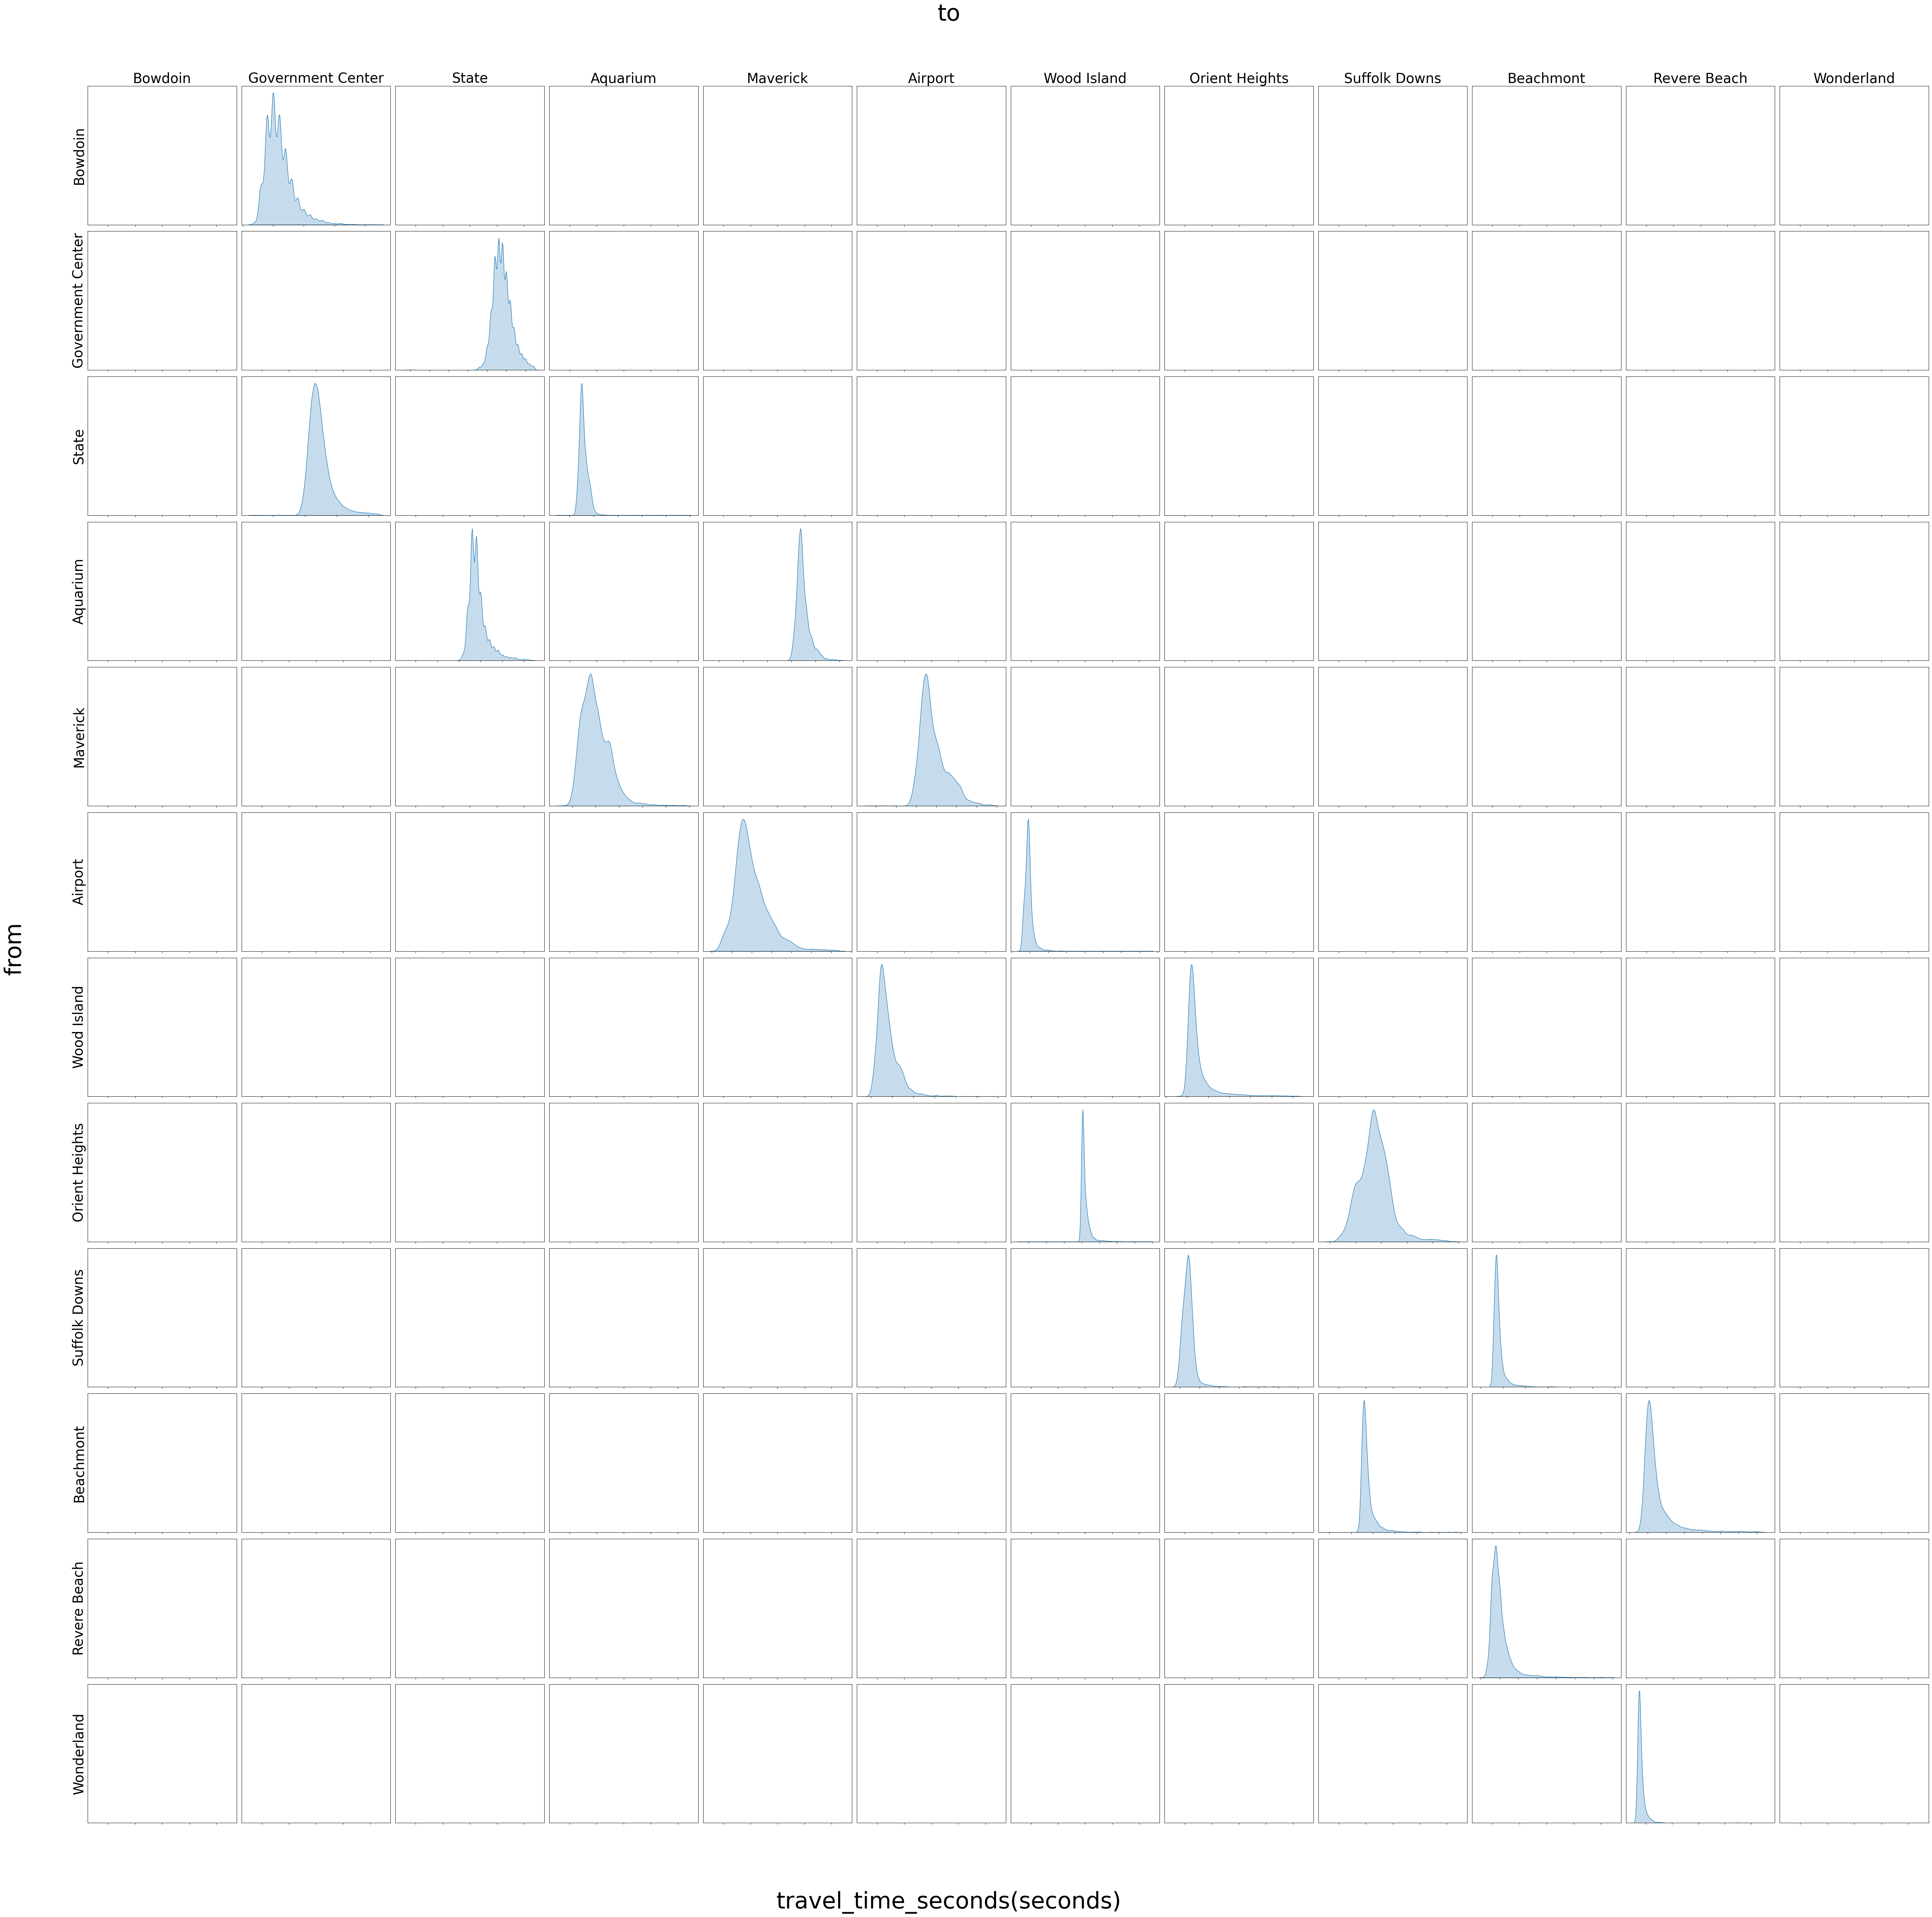

In [196]:
plot_kde(blue, 'travel_time_seconds', blue_stops)

C:\Users\prade\AppData\Local\Temp\ipykernel_9392\105765718.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\105765718.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\105765718.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\105765718.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ip

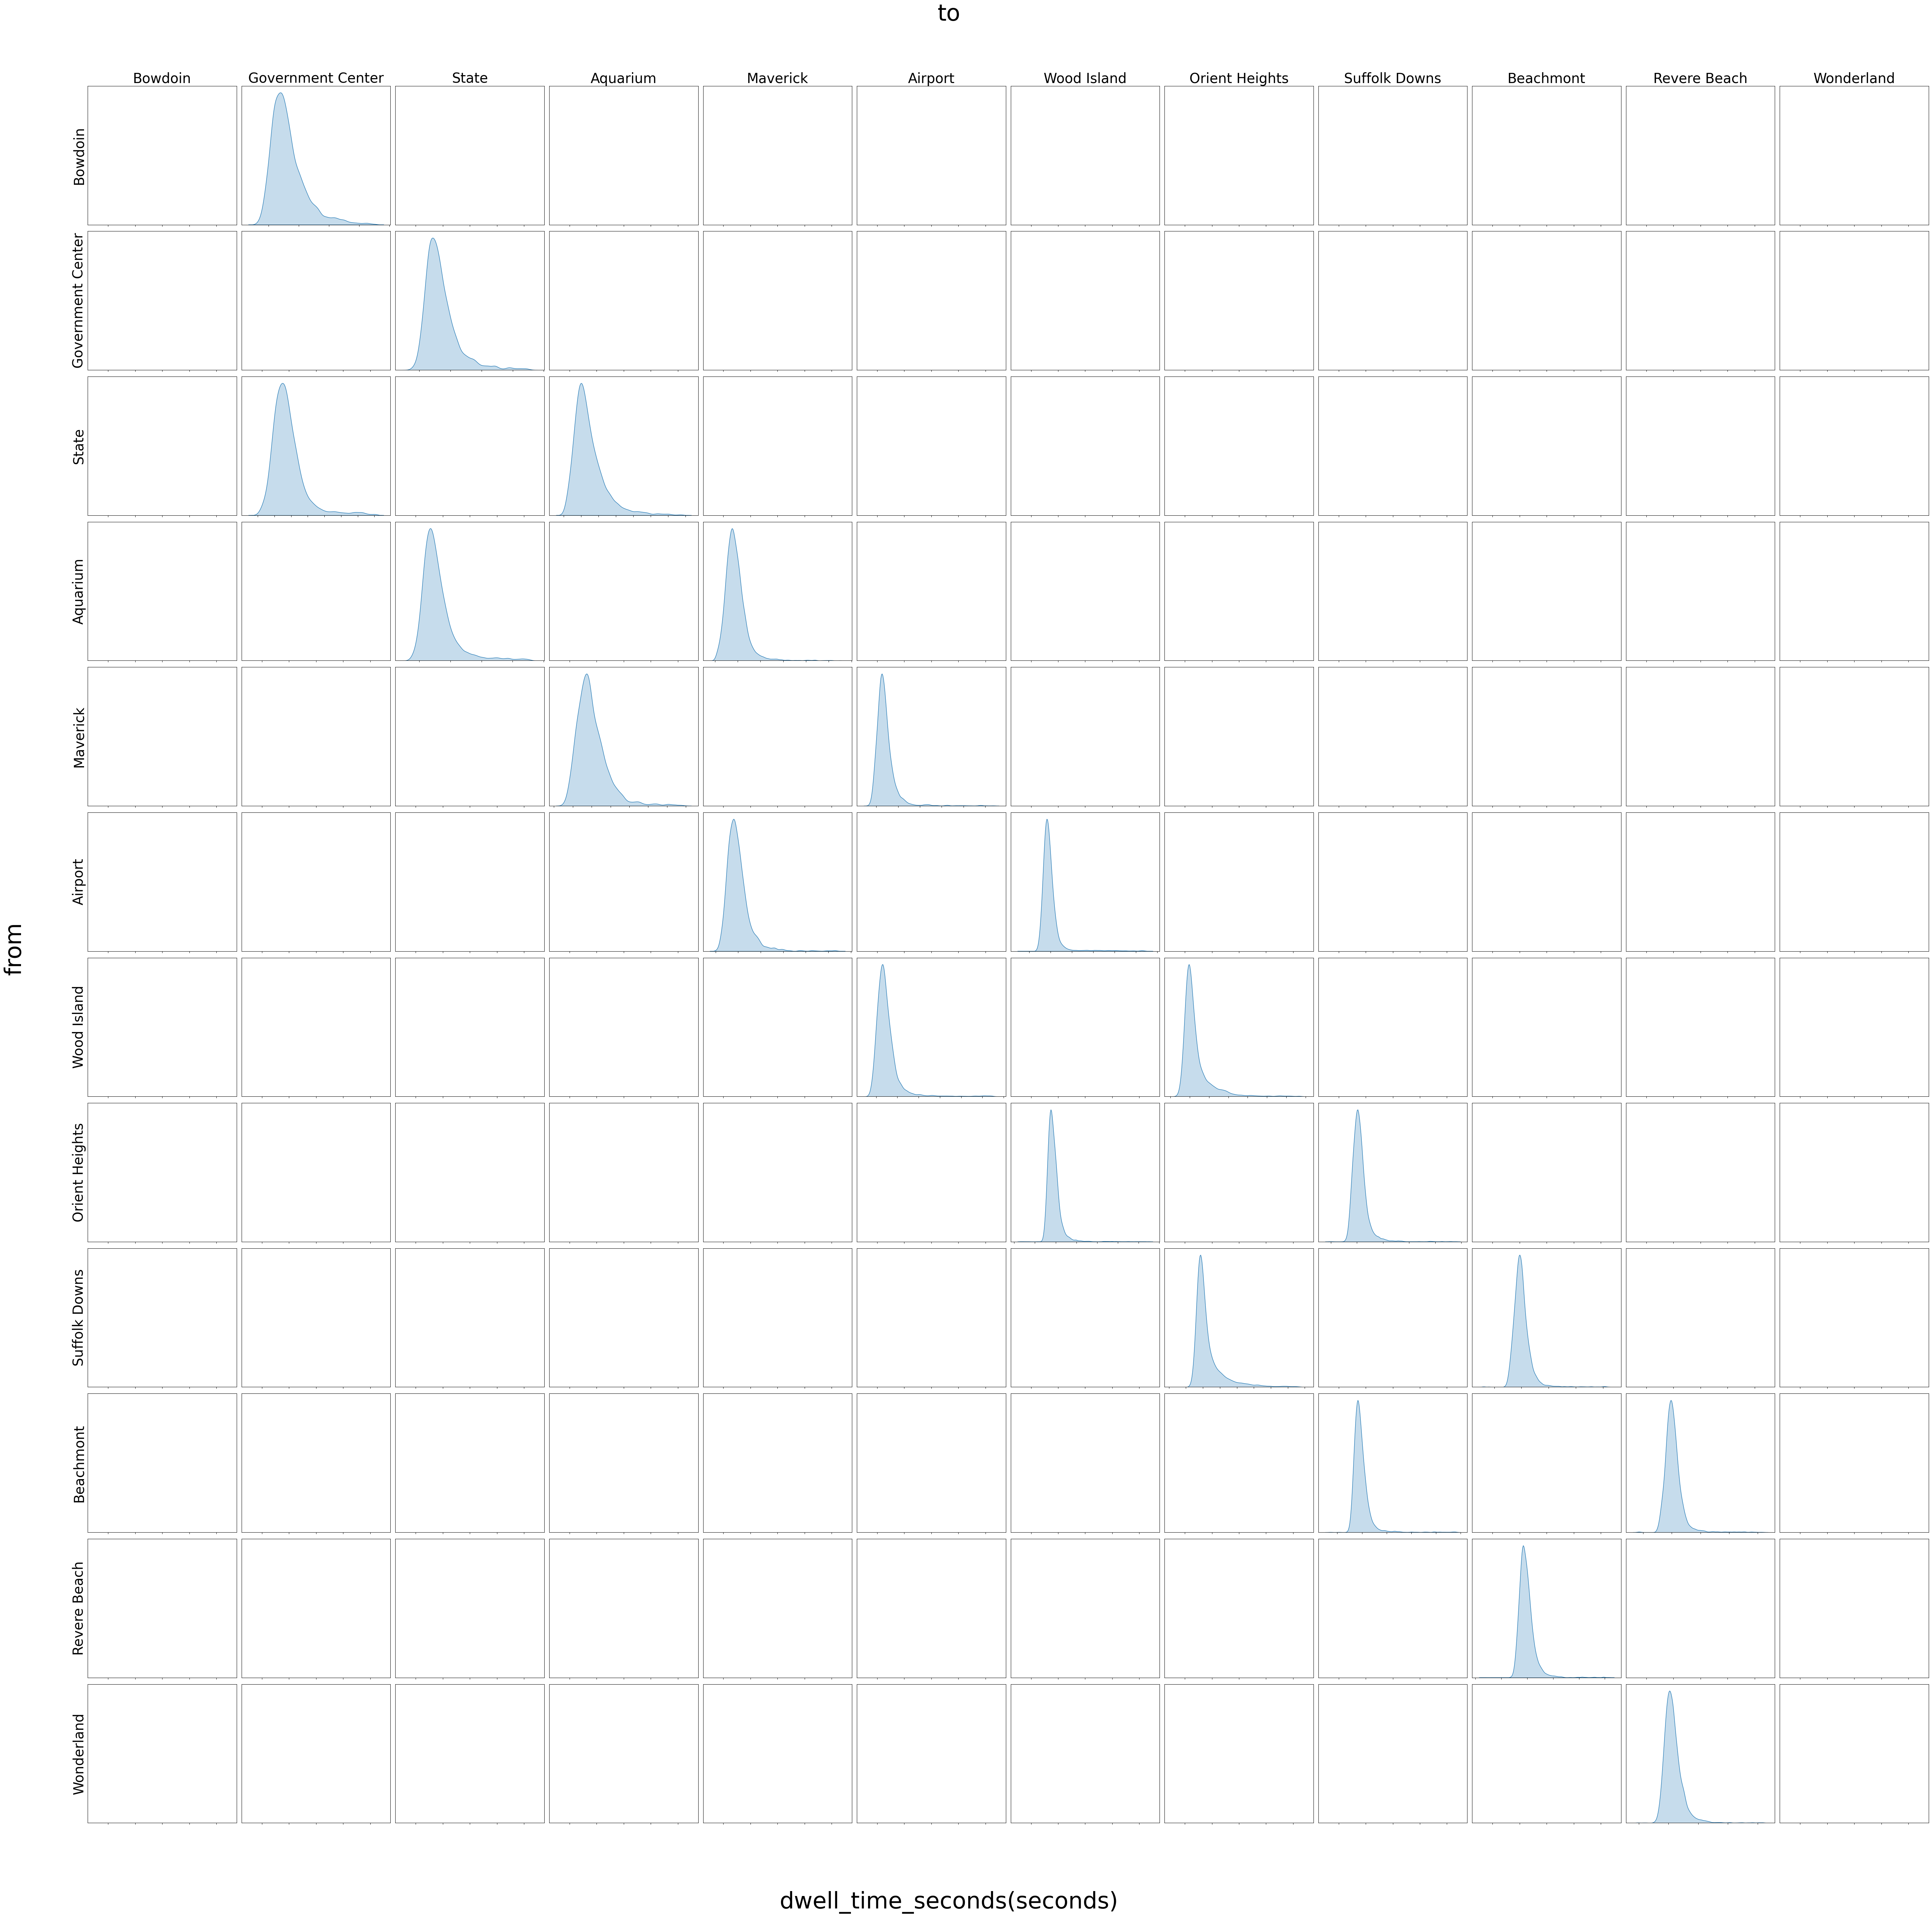

In [197]:
plot_kde(blue, 'dwell_time_seconds', blue_stops)

## find best fit distribution

In [201]:
from_station = blue_stops[0]
to_station = blue_stops[1]

temp = blue.loc[(blue['fromstation']==from_station) & (blue['stop_name']==to_station)]

In [202]:
get_aic(blue, 'travel_time_seconds')

weibull_min          73154.19
lognorm              64354.93
gamma                65144.94
expon               108317.93
burr                 59295.46
inverse_gaussian     64520.90
log_logistic         61239.31
dtype: float64


In [203]:
get_aic(blue, 'dwell_time_seconds')

weibull_min          82619.65
lognorm              75020.48
gamma                76206.66
expon               104563.52
burr                 72038.16
inverse_gaussian     75176.29
log_logistic         73205.28
dtype: float64


In [251]:
distribution = scipy.stats.burr

## get distribution parameters (sigma, scale)

In [252]:
def get_gamma_params(df, distribution):
    ret_df = {
    'from_station':     [],
    'to_station':       [],
    'dwell_params':     [],
    'travel_params':    [],
    'direction':        []
    }

    dist = distribution
    key = [s.name for s in dist._shape_info()] + ['loc', 'scale']

    for from_station in df['fromstation'].unique():
        temp = df[df['fromstation']==from_station]
        for to_station in temp['stop_name'].unique():
            dwell_time = df[(df['stop_name']==to_station)&(df['fromstation']==from_station)]['dwell_time_seconds']
            travel_time = df[(df['stop_name']==to_station)&(df['fromstation']==from_station)]['travel_time_seconds']
            direction = df[(df['stop_name']==to_station)&(df['fromstation']==from_station)]['direction_id'].mean()

            ret_df['from_station'].append(from_station)
            ret_df['to_station'].append(to_station)
            ret_df['dwell_params'].append(dict(zip(key, dist.fit(dwell_time, floc=0))))
            ret_df['travel_params'].append(dict(zip(key, dist.fit(travel_time, floc=0))))
            ret_df['direction'].append(bool(direction))

    return pd.DataFrame(ret_df)

In [253]:
params_df = get_gamma_params(blue, distribution)
params_df['dwell_params'] = params_df['dwell_params'].apply(lambda x: {key: round(float(value),2) for key, value in x.items()})
params_df['travel_params'] = params_df['travel_params'].apply(lambda x: {key: round(float(value),2) for key, value in x.items()}) 

In [254]:
params_df

,from_station,to_station,dwell_params,travel_params,direction
0,Orient Heights,Wood Island,"{'c': 10.4, 'd': 2.73, 'loc': 0.0, 'scale': 32...","{'c': 32.26, 'd': 3.65, 'loc': 0.0, 'scale': 9...",False
1,Orient Heights,Suffolk Downs,"{'c': 11.37, 'd': 4.12, 'loc': 0.0, 'scale': 3...","{'c': 17.12, 'd': 1.07, 'loc': 0.0, 'scale': 5...",True
2,Wood Island,Airport,"{'c': 7.79, 'd': 53.19, 'loc': 0.0, 'scale': 2...","{'c': 16.7, 'd': 1409.55, 'loc': 0.0, 'scale':...",False
3,Wood Island,Orient Heights,"{'c': 6.05, 'd': 806.31, 'loc': 0.0, 'scale': ...","{'c': 18.27, 'd': 3056.07, 'loc': 0.0, 'scale'...",True
4,Wonderland,Revere Beach,"{'c': 11.12, 'd': 3.07, 'loc': 0.0, 'scale': 3...","{'c': 23.49, 'd': 1435.46, 'loc': 0.0, 'scale'...",False
5,Airport,Maverick,"{'c': 9.02, 'd': 6.34, 'loc': 0.0, 'scale': 45.5}","{'c': 16.67, 'd': 5.81, 'loc': 0.0, 'scale': 8...",False
6,Airport,Wood Island,"{'c': 9.05, 'd': 8.38, 'loc': 0.0, 'scale': 28...","{'c': 17.0, 'd': 103.62, 'loc': 0.0, 'scale': ...",True
7,Revere Beach,Beachmont,"{'c': 10.77, 'd': 2.78, 'loc': 0.0, 'scale': 3...","{'c': 43.95, 'd': 1976.02, 'loc': 0.0, 'scale'...",False
8,Beachmont,Suffolk Downs,"{'c': 10.73, 'd': 4.67, 'loc': 0.0, 'scale': 3...","{'c': 27.56, 'd': 11.54, 'loc': 0.0, 'scale': ...",False
9,Beachmont,Revere Beach,"{'c': 11.81, 'd': 2.13, 'loc': 0.0, 'scale': 3...","{'c': 18.34, 'd': 2186.67, 'loc': 0.0, 'scale'...",True


## complete table; fill in missing edge

In [255]:
params_df = pd.concat([params_df,
          pd.DataFrame({
              'from_station':['Government Center', 'Revere Beach'],
              'to_station':['Bowdoin','Wonderland'],
              'dwell_params':[
                  params_df[(params_df['from_station']=='Bowdoin')&(params_df['to_station']=='Government Center')]['dwell_params'].iloc[0],
                  params_df[(params_df['from_station']=='Wonderland')&(params_df['to_station']=='Revere Beach')]['dwell_params'].iloc[0]
              ],
              'travel_params':[
                  params_df[(params_df['from_station']=='Bowdoin')&(params_df['to_station']=='Government Center')]['travel_params'].iloc[0],
                  params_df[(params_df['from_station']=='Wonderland')&(params_df['to_station']=='Revere Beach')]['travel_params'].iloc[0]
              ],
              'direction':[
                  False,
                  True
              ]

          })], ignore_index=True)

## compare distribution from empirical distribution

In [256]:
# plot kernel density
def compare_kde(df1, feat1, df2, feat2, ind_col, distribution):
    l = len(ind_col)
    fig, axes = plt.subplots(l, l, figsize=(5*l, 5*l))
    fig.supxlabel(f'\n\n\n{feat1}(seconds)', fontsize=50)
    fig.supylabel('from\n\n\n', fontsize=50)
    fig.suptitle('to\n\n\n', fontsize=50)
    
    dist = distribution

    for i in range(l):
        for j in range(l):
            temp = df1.loc[(df1['fromstation']==ind_col[i]) & (df1['stop_name']==ind_col[j])]
            sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])

            temp = df2.loc[(df2['from_station']==ind_col[i]) & (df2['to_station']==ind_col[j])]
            if not(temp.empty):
                data = dist(**temp[feat2].iloc[0]).rvs(size=4000)
                sns.kdeplot(data=data, fill=True, ax=axes[i, j])

            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')
            if j==0:
                axes[i, j].set_ylabel(ind_col[i], fontsize=30)
            if i==0:
                axes[i, j].set_title(ind_col[j], fontsize=30)
            
            axes[i, j].set_xlabel('')

            # Remove tick labels
            axes[i, j].set_xticklabels([])
            axes[i, j].set_yticklabels([])
            
            # Also remove the ticks themselves
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
    
    plt.tight_layout()
    plt.show()

C:\Users\prade\AppData\Local\Temp\ipykernel_9392\350413379.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\350413379.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\350413379.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\350413379.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Tem

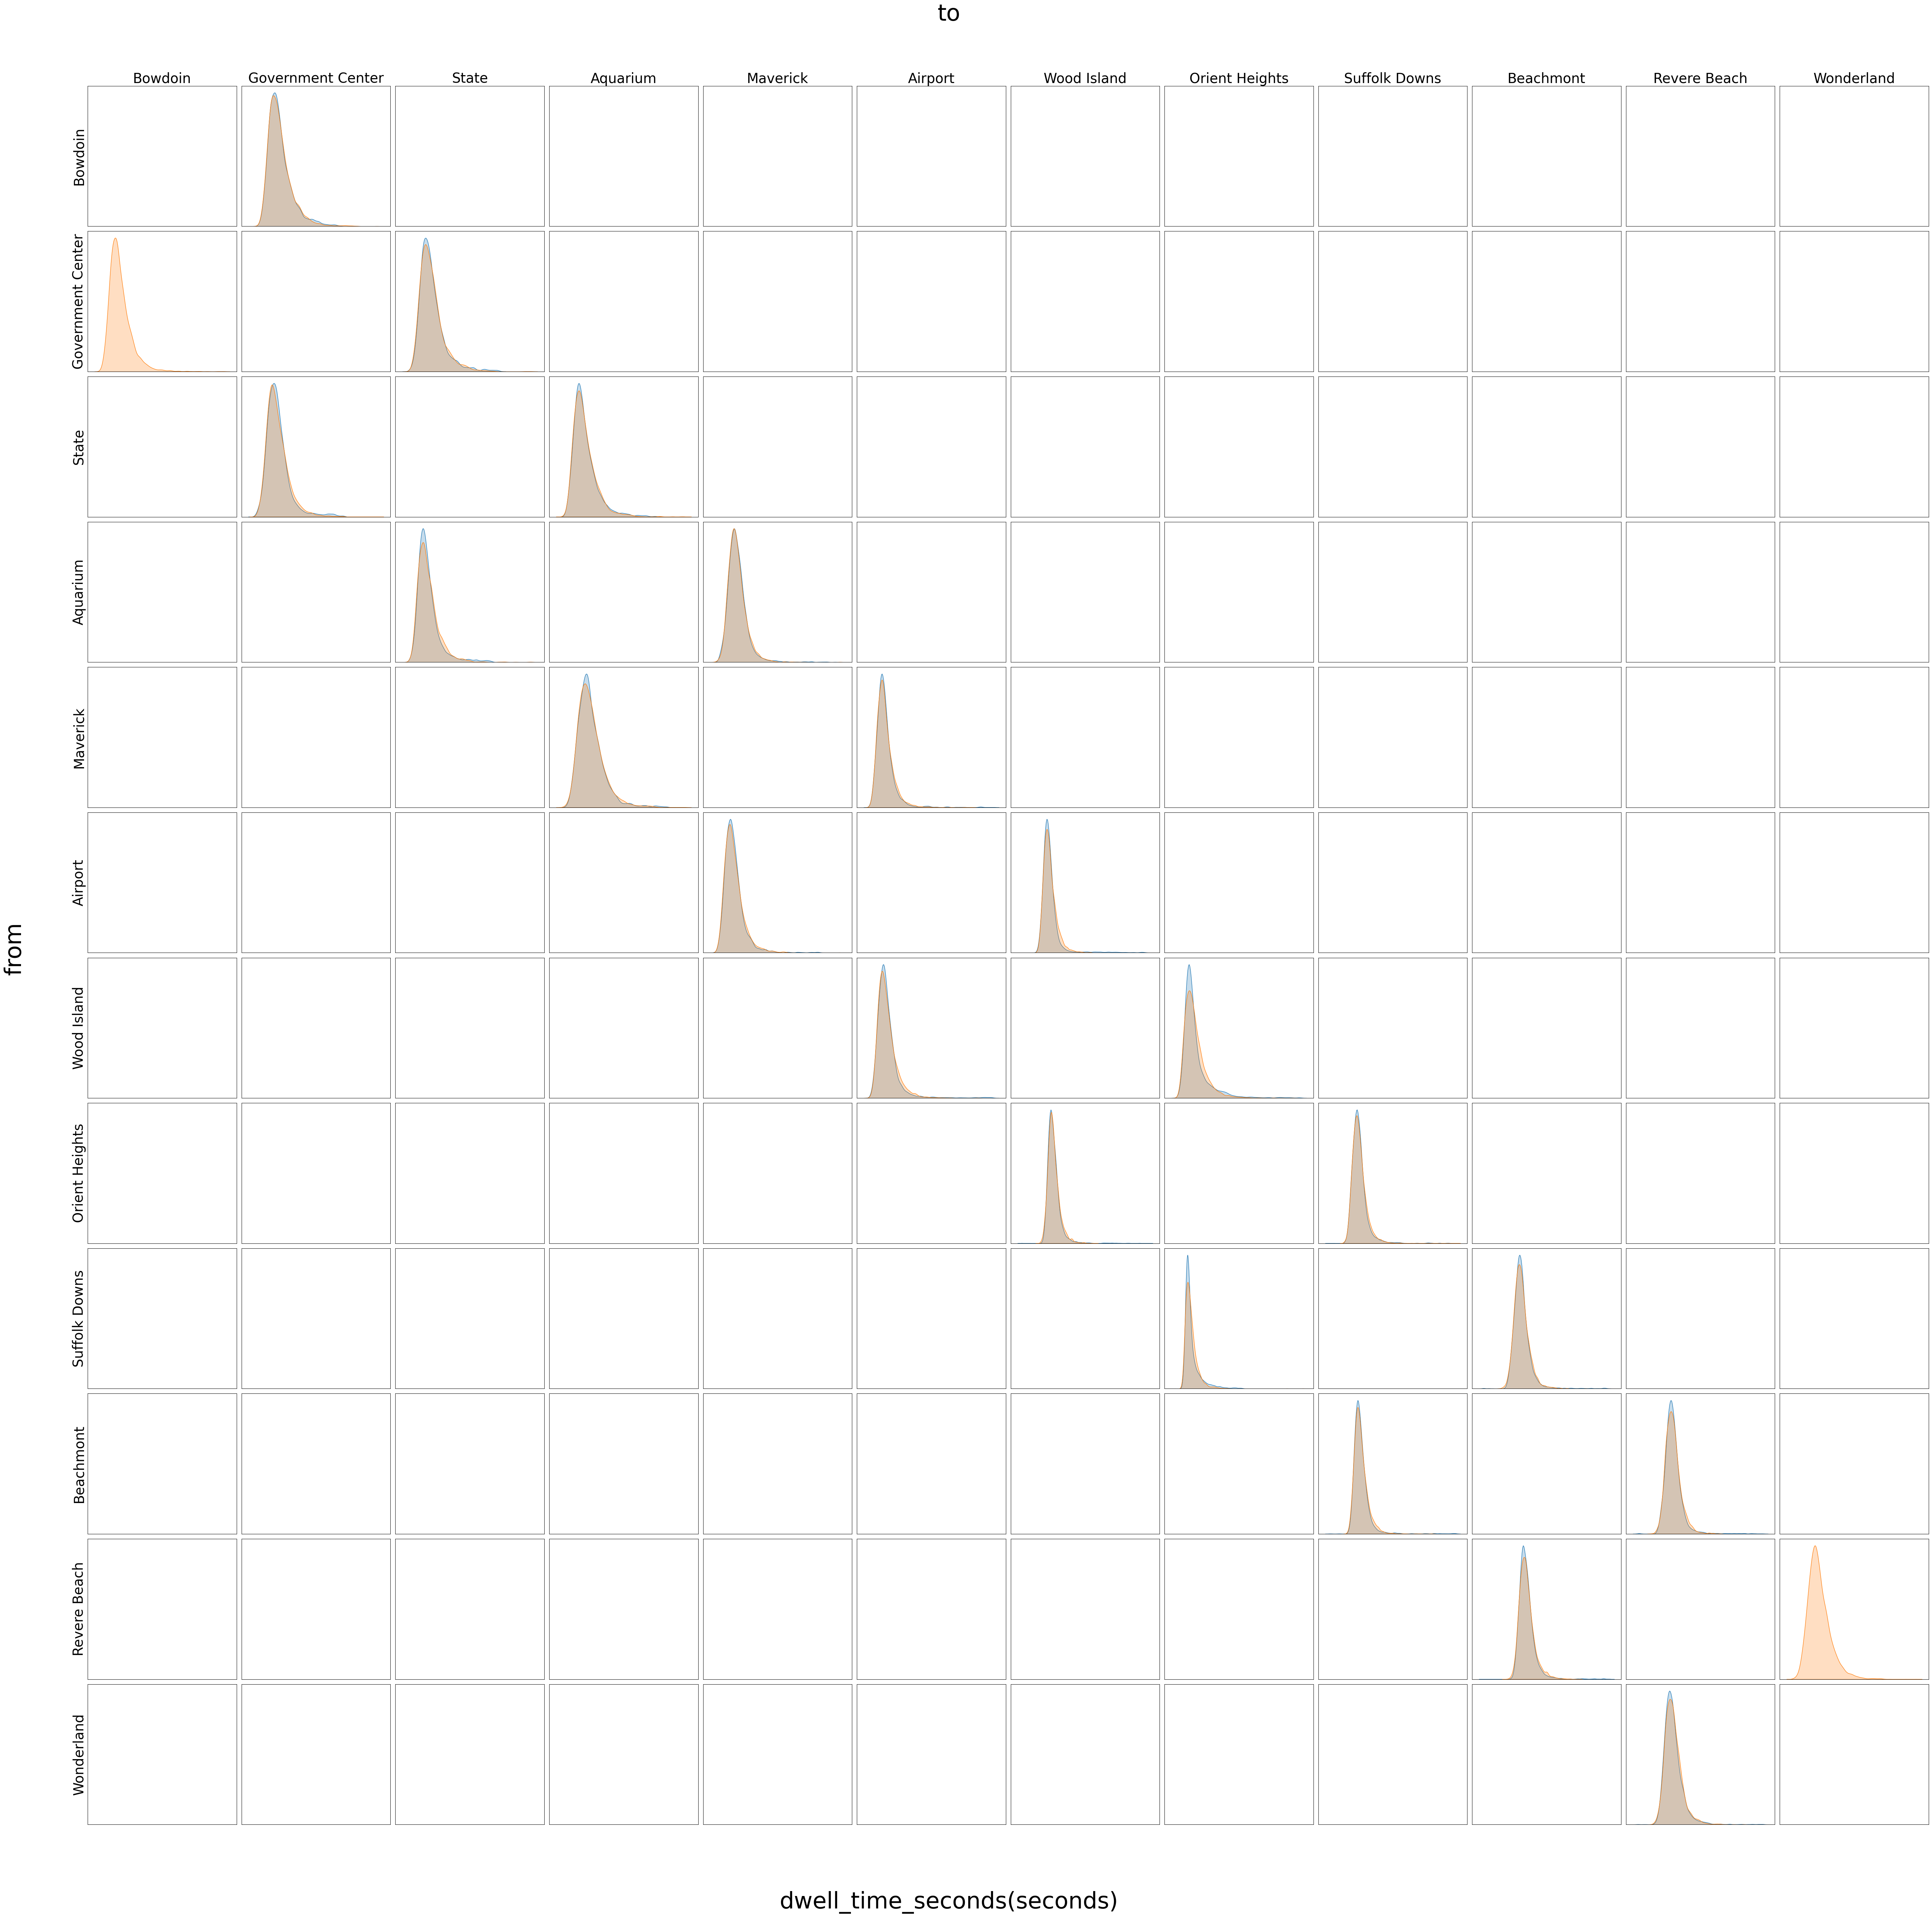

In [257]:
compare_kde(blue, 'dwell_time_seconds', params_df, 'dwell_params', blue_stops, distribution)

C:\Users\prade\AppData\Local\Temp\ipykernel_9392\350413379.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\350413379.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\350413379.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_9392\350413379.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat1, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Tem

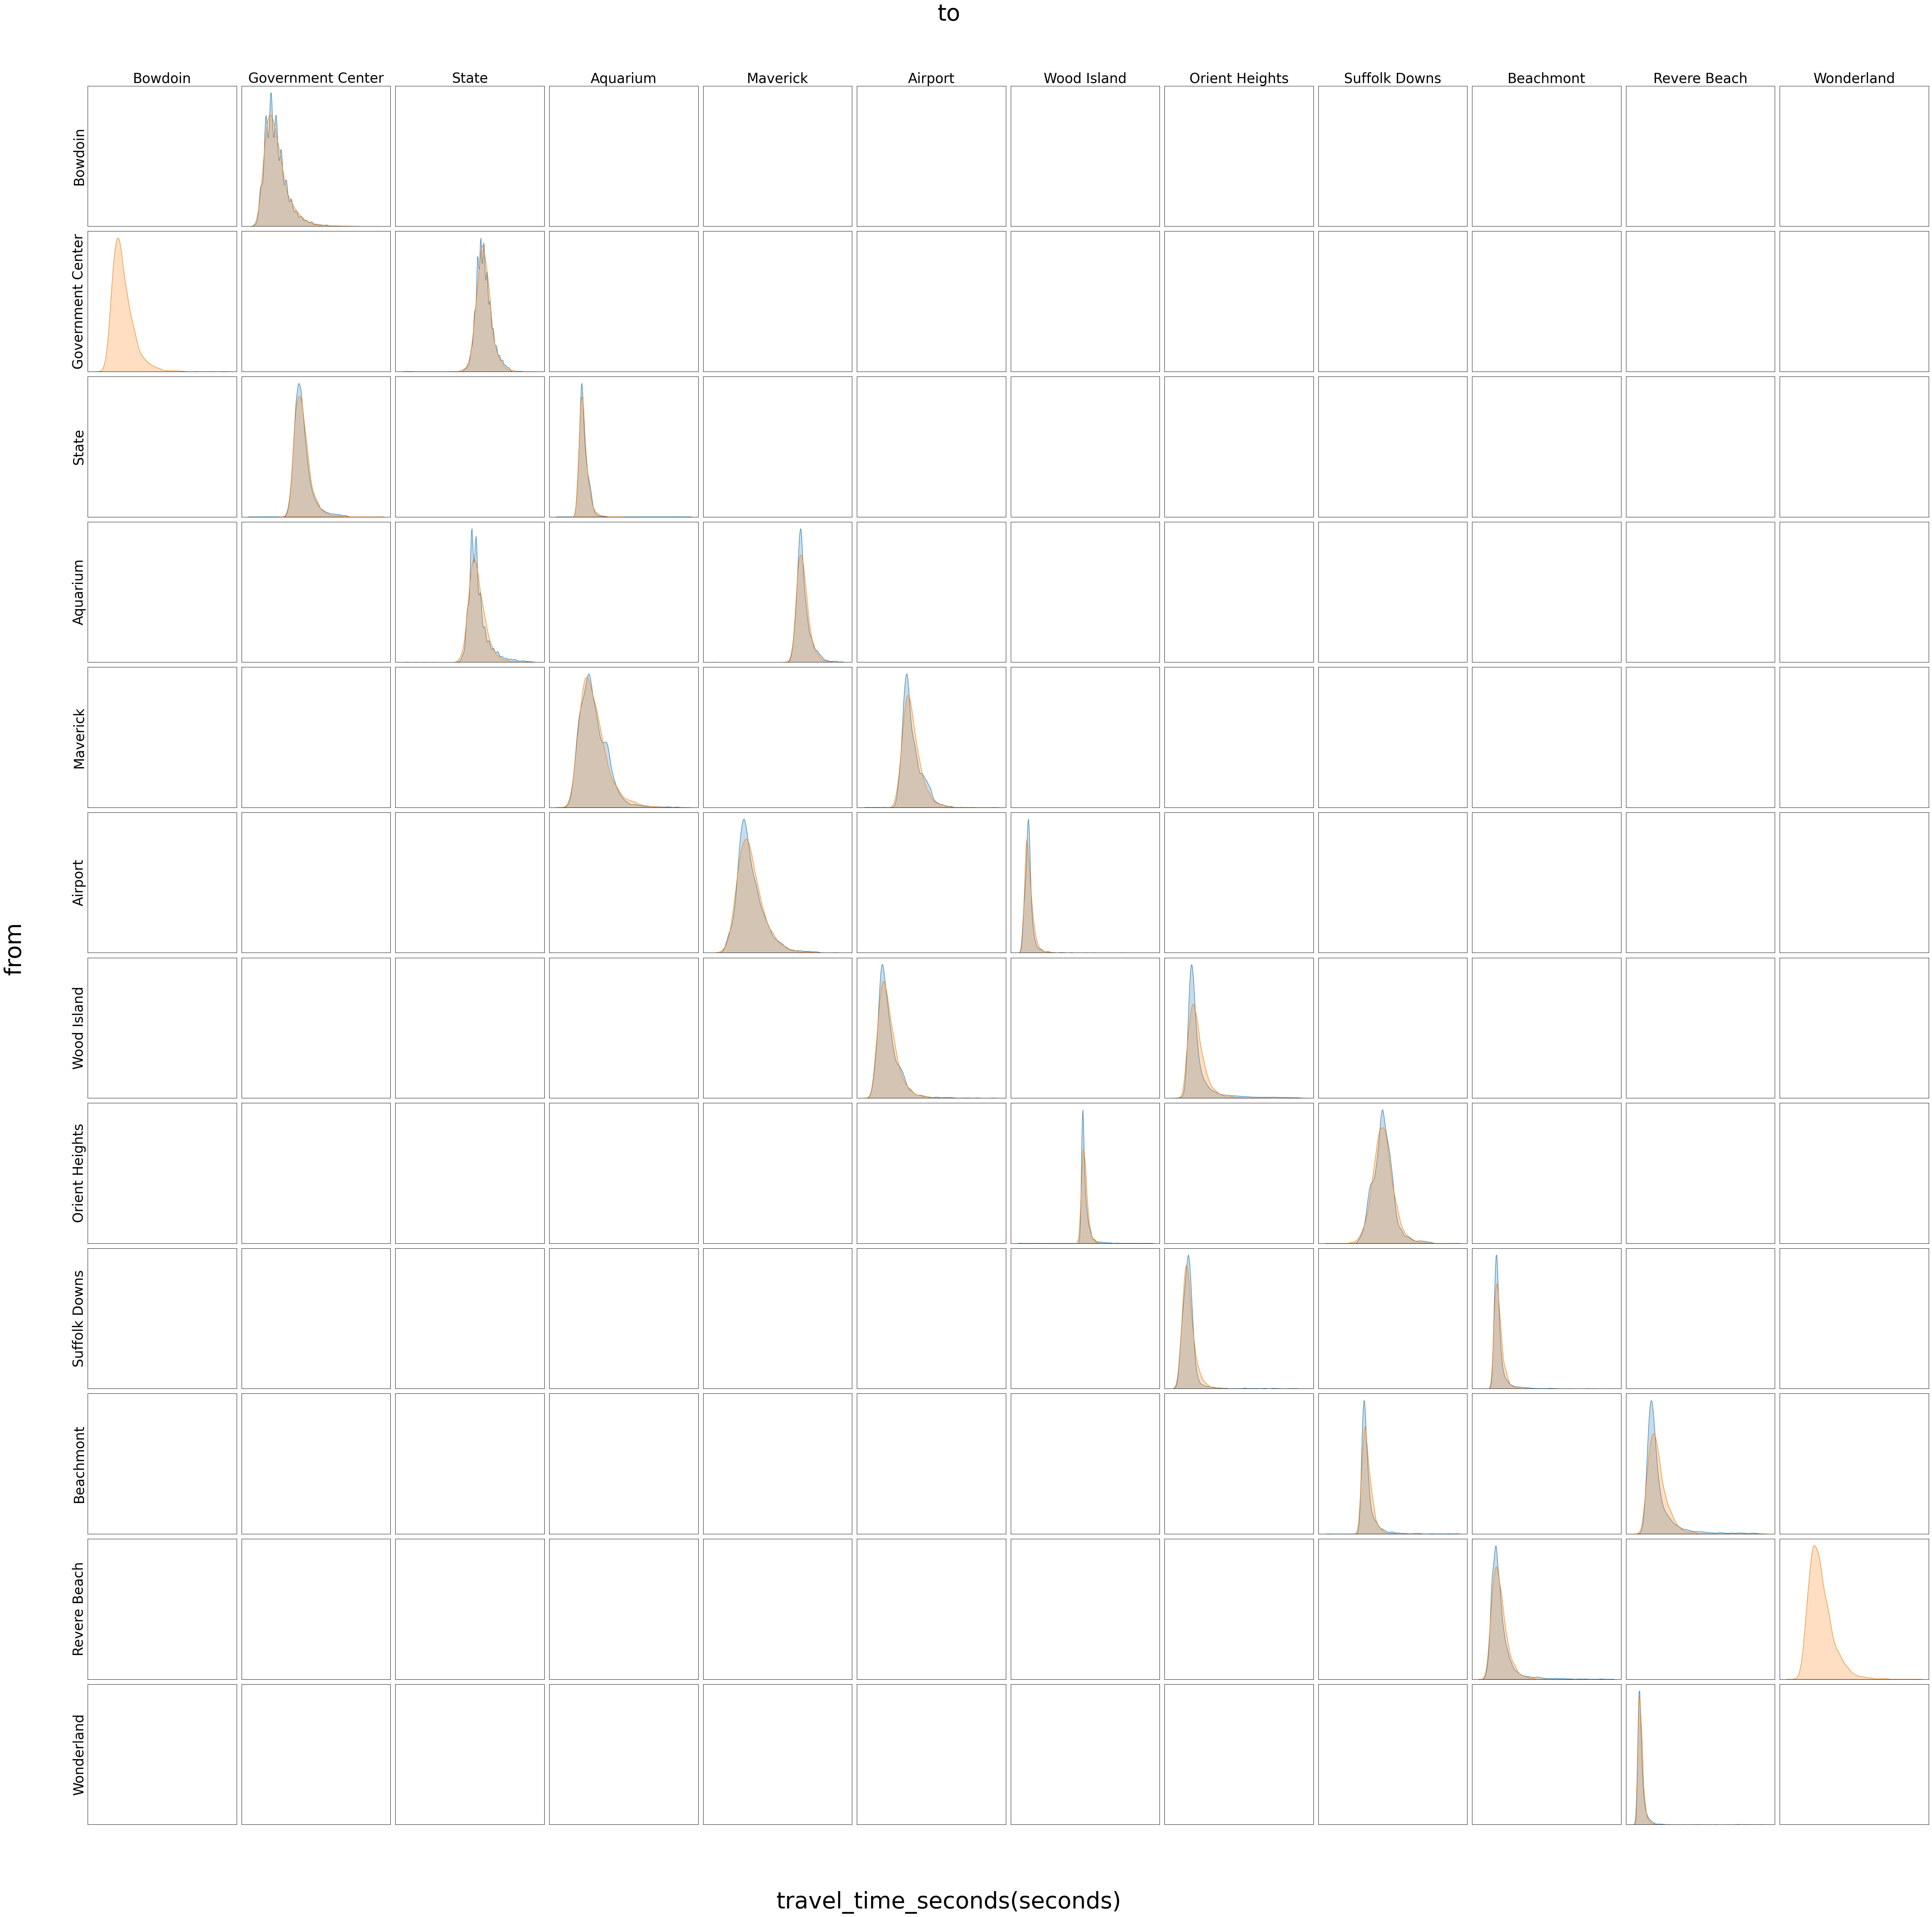

In [258]:
compare_kde(blue, 'travel_time_seconds', params_df, 'travel_params', blue_stops, distribution)

## generate  network

blue_network = {    
    'station':  
    {   
    True:   {'dwell_time':{},   
              'next_station':{'name', 'travel_time'}},  
    False:  {'dwell_time':{},   
              'next_station':{'name', 'travel_time'}}   
    }}

In [259]:
blue_stops = ['Bowdoin' ,'Government Center', 'State', 'Aquarium',
                'Maverick', 'Airport', 'Wood Island',
                'Orient Heights', 'Suffolk Downs', 
                'Beachmont', 'Revere Beach', 'Wonderland']


In [260]:
def generate_stations(stops, df):
    station_network = {
        station: {True: {}, False: {}}
        for station in stops
    }

    for station in stops:
         for b in [True, False]:
            temp = df[(df['from_station']==station)&(df['direction']==b)]
            # travel_params
            if not(temp.empty):
                name = temp['to_station'].iloc[0]
                travel_params = temp['travel_params'].iloc[0]
                station_network[station][b]['next_station'] = {
                    'name': name,
                    'travel_params': travel_params
                }
            temp = df[(df['to_station']==station)&(df['direction']==b)]
            # dwell_params
            if not(temp.empty):
                dwell_params = temp['dwell_params'].iloc[0]
                station_network[station][b]['dwell_params'] = dwell_params

    return station_network

In [261]:
blue_network = generate_stations(blue_stops, params_df)

In [262]:
pprint(blue_network)

{'Airport': {False: {'dwell_params': {'c': 7.79,
                                      'd': 53.19,
                                      'loc': 0.0,
                                      'scale': 27.2},
                     'next_station': {'name': 'Maverick',
                                      'travel_params': {'c': 16.67,
                                                        'd': 5.81,
                                                        'loc': 0.0,
                                                        'scale': 87.0}}},
             True: {'dwell_params': {'c': 9.01,
                                     'd': 10.99,
                                     'loc': 0.0,
                                     'scale': 34.24},
                    'next_station': {'name': 'Wood Island',
                                     'travel_params': {'c': 17.0,
                                                       'd': 103.62,
                                                       'loc': 0.0,
 

In [263]:
# save as pickle
with open(r'..\data\blue_network.pkl', 'wb') as f:
    pickle.dump(blue_network, f)

In [264]:
blue

,stop_name,route_id,travel_time_seconds,dwell_time_seconds,headway_trunk_seconds,direction_id,direction_destination,scheduled_travel_time,scheduled_headway_trunk,fromstation
61,Wood Island,Blue,114.0,55.0,NaN,False,Bowdoin,120.0,240.0,Orient Heights
82,Airport,Blue,60.0,51.0,NaN,False,Bowdoin,120.0,240.0,Wood Island
92,Revere Beach,Blue,35.0,48.0,NaN,False,Bowdoin,60.0,NaN,Wonderland
100,Maverick,Blue,100.0,56.0,NaN,False,Bowdoin,120.0,240.0,Airport
106,Beachmont,Blue,68.0,38.0,NaN,False,Bowdoin,120.0,NaN,Revere Beach
...,...,...,...,...,...,...,...,...,...,...
2320083,Airport,Blue,72.0,42.0,2065.0,True,Wonderland,120.0,1020.0,Maverick
2320092,Wood Island,Blue,55.0,35.0,2382.0,True,Wonderland,120.0,1020.0,Airport
2320102,Orient Heights,Blue,103.0,35.0,2301.0,True,Wonderland,120.0,1020.0,Wood Island
2320113,Suffolk Downs,Blue,54.0,41.0,3203.0,True,Wonderland,60.0,1020.0,Orient Heights
